# Stations distribution — Figure 2 + Table 2

Mean environmental conditions (temperature and net primary production) at the
six oceanographic stations, placed within the global distribution of ocean
grid cells (Manuscript Section 2.3, Table 2, Figure 2).

Inputs: `data/forcings_global.zarr`, `data/stations_coords.json`.
Output: `figures/Figure_2.{pdf,png}` and the printed Table 2 DataFrame.
Runtime: ~1 minute.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / "stations_coords.json") as f:
    STATIONS = json.load(f)

# Tol color-blind friendly palette
COLORS = ["#332288", "#88CCEE", "#44AA99", "#117733", "#DDCC77", "#CC6677"]
MARKERS = ["s", "^", "D", "v", "o", "p"]

sns.set_context("paper", font_scale=1.3)
sns.set_style("white", {"axes.edgecolor": "black", "axes.linewidth": 0.8})

## Global climatology

Time mean of temperature and NPP per 1° cell over 1998–2019, then flatten
to the set of ocean grid cells with valid data for both variables.

In [2]:
forcings = xr.open_zarr(DATA_DIR / "forcings_global.zarr")
temperature = forcings["temperature"]
npp = forcings["npp"]

temp_mean_global = temperature.mean(dim="T").compute()
npp_mean_global = npp.mean(dim="T").compute()

temp_flat = temp_mean_global.values.flatten()
npp_flat = npp_mean_global.values.flatten()
valid = ~(np.isnan(temp_flat) | np.isnan(npp_flat))
temp_clean = temp_flat[valid]
npp_clean = npp_flat[valid]

len(temp_clean), float(temp_clean.min()), float(temp_clean.max())

(42833, -1.8069491386413574, 30.32794952392578)

## Per-station statistics — Table 2

Nearest-neighbour 1° cell for each station, then mean and inter-quartile
range (Q25–Q75) of the time series.

In [3]:
rows = []
station_stats = {}

for sid, info in STATIONS.items():
    lat_idx = int(np.abs(temperature["Y"] - info["lat"]).argmin().values)
    lon_idx = int(np.abs(temperature["X"] - info["lon"]).argmin().values)
    t_series = temperature.isel(Y=lat_idx, X=lon_idx).values
    p_series = npp.isel(Y=lat_idx, X=lon_idx).values
    m = ~(np.isnan(t_series) | np.isnan(p_series))
    t_valid, p_valid = t_series[m], p_series[m]

    stats = {
        "name": info["label"],
        "lat": info["lat"],
        "lon": info["lon"],
        "temp_mean": float(np.mean(t_valid)),
        "temp_q25": float(np.percentile(t_valid, 25)),
        "temp_q75": float(np.percentile(t_valid, 75)),
        "npp_mean": float(np.mean(p_valid)),
        "npp_q25": float(np.percentile(p_valid, 25)),
        "npp_q75": float(np.percentile(p_valid, 75)),
    }
    station_stats[sid] = stats
    rows.append(stats)

table_2 = pd.DataFrame(rows).set_index("name")[
    ["lat", "lon", "temp_mean", "temp_q25", "temp_q75", "npp_mean", "npp_q25", "npp_q75"]
].round(2)
table_2

/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


,lat,lon,temp_mean,temp_q25,temp_q75,npp_mean,npp_q25,npp_q75
name,,,,,,,,
BARENTS,75.0,40.0,0.66,-0.32,1.59,68.77,0.00,112.67
PAPA,50.0,-132.0,9.21,7.84,10.48,317.38,219.22,398.81
Bay of Biscay,45.5,-4.0,13.94,12.59,15.32,519.47,358.73,558.27
BATS,32.0,-64.0,21.50,20.43,22.58,269.75,159.58,369.64
Canary,30.0,-13.0,19.30,18.46,20.16,486.89,402.23,542.29
HOT,23.0,-158.0,23.86,23.28,24.44,258.55,214.58,296.25


## Figure 2 — Environmental envelope with stations

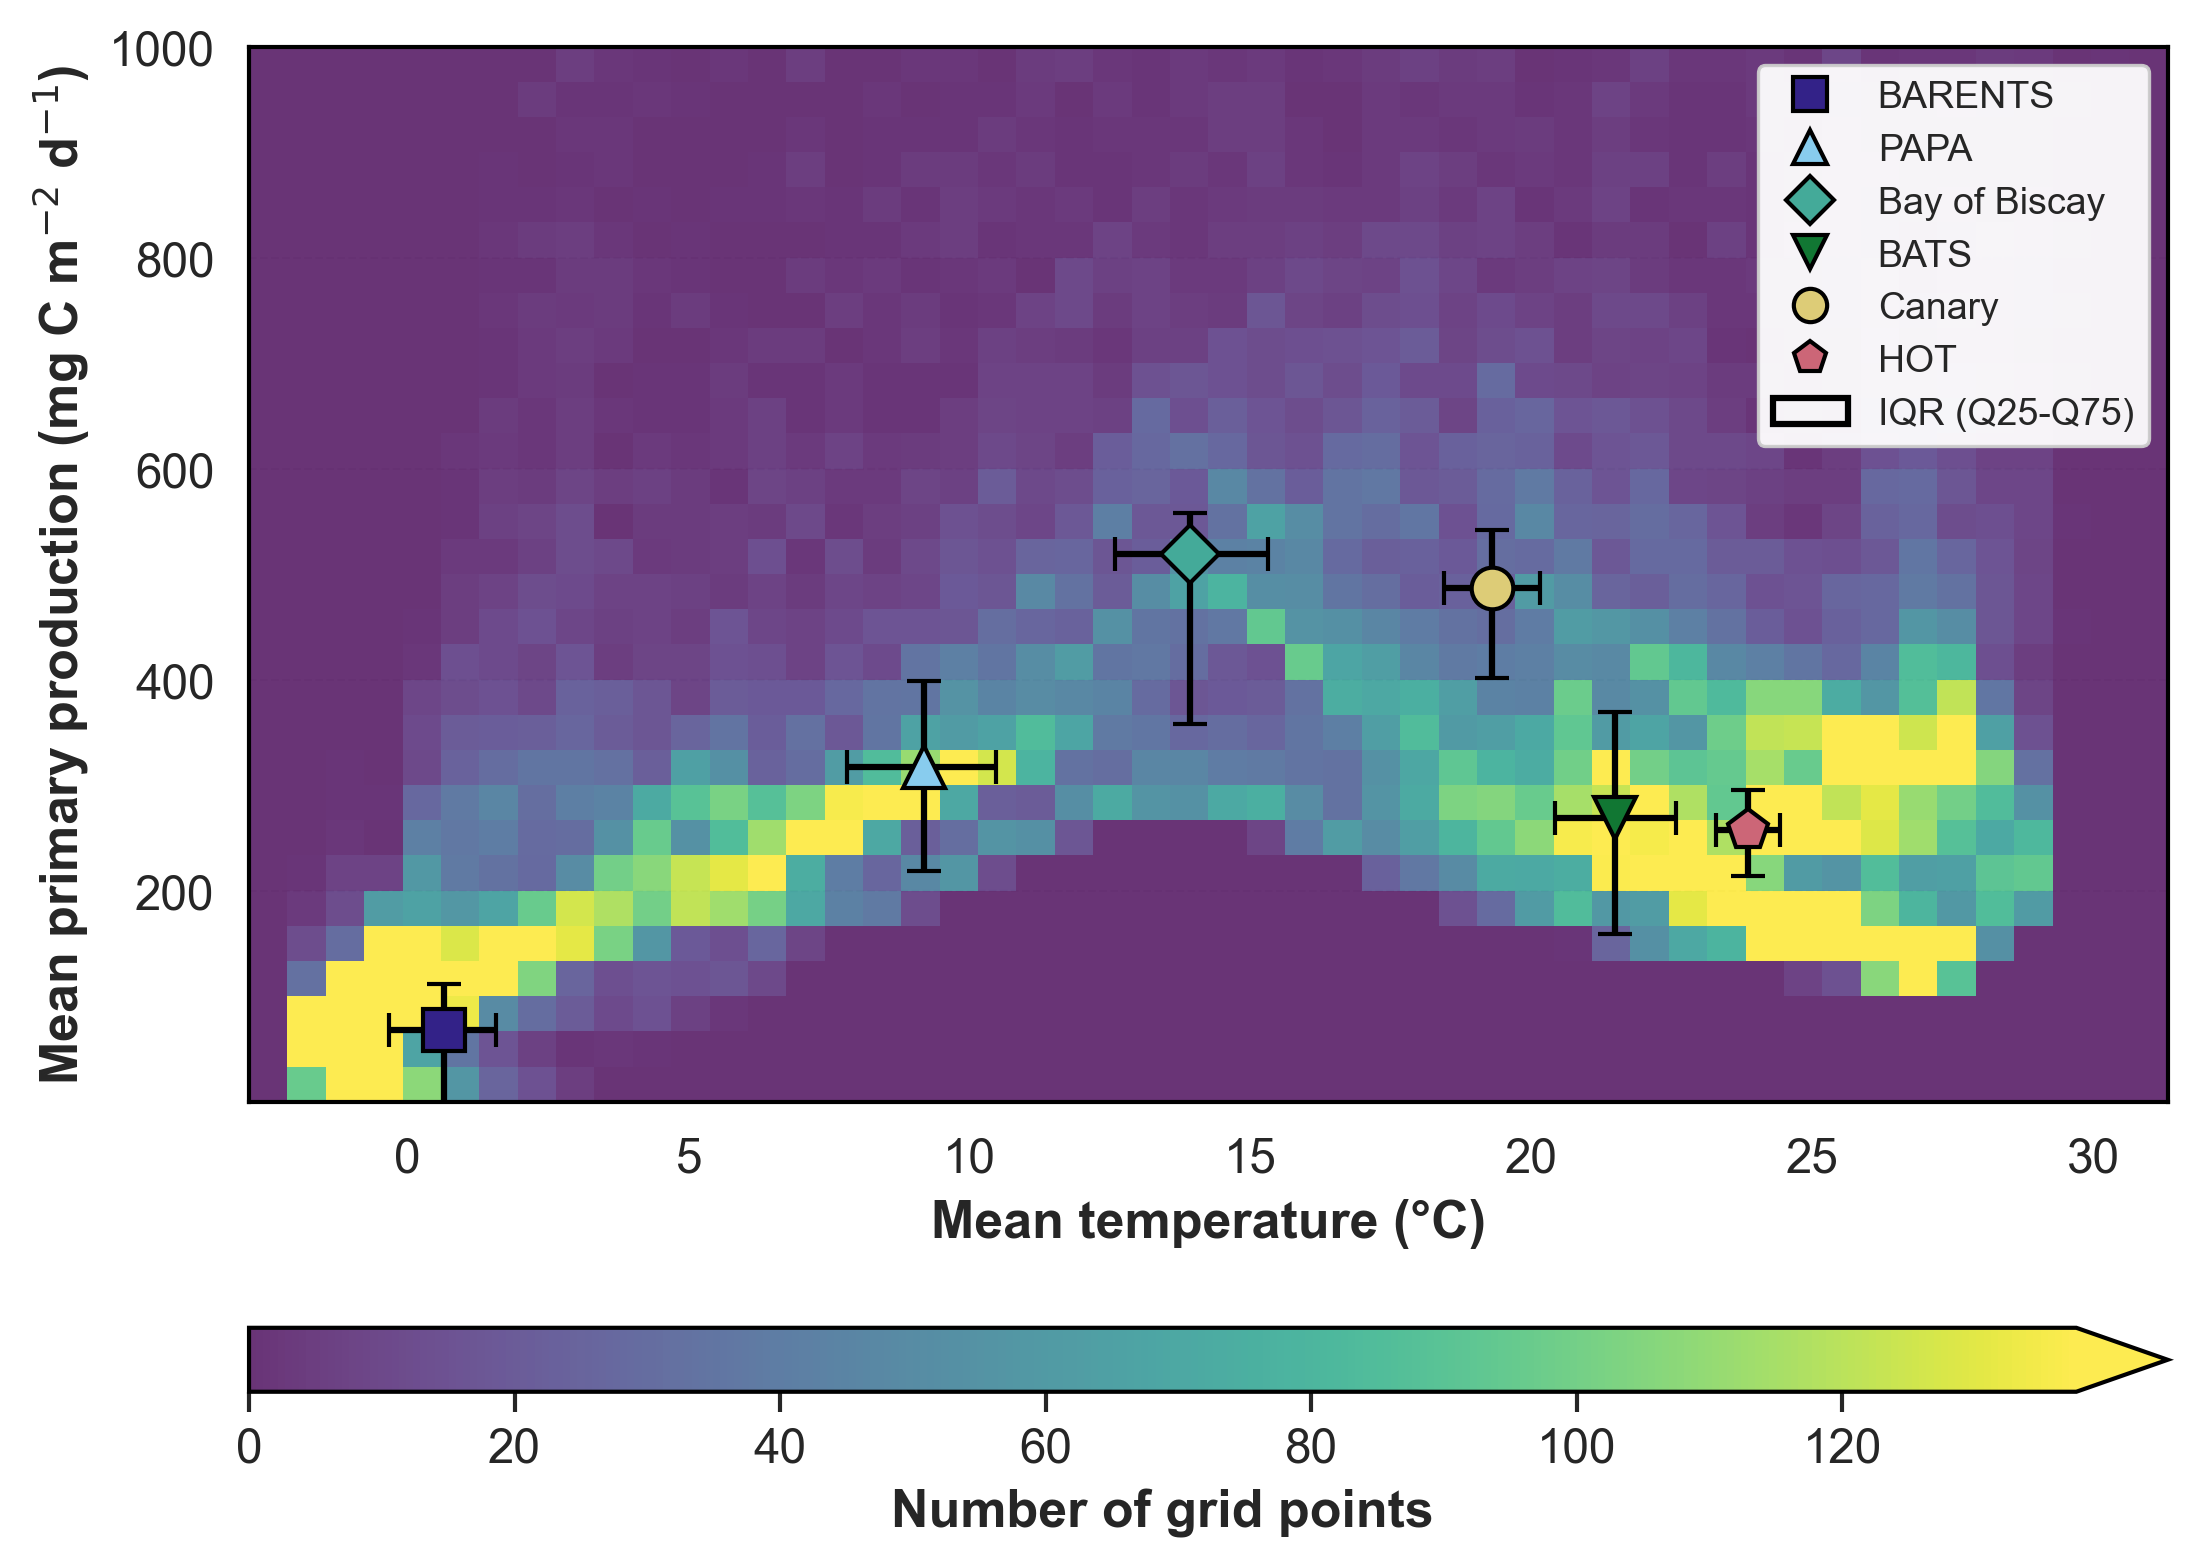

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=300)

x_min, x_max = float(temp_clean.min()) - 1, float(temp_clean.max()) + 1
y_min, y_max = float(npp_clean.min()) * 0.95, 1000.0
bins = [50, 30]

counts, _, _ = np.histogram2d(temp_clean, npp_clean, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
vmax = float(np.percentile(counts[counts > 0], 95))

heatmap = ax.hist2d(
    temp_clean, npp_clean,
    bins=bins, range=[[x_min, x_max], [y_min, y_max]],
    cmap="viridis", cmin=0, vmax=vmax, alpha=0.8,
)
cbar = plt.colorbar(heatmap[3], ax=ax, orientation="horizontal", pad=0.15, aspect=30, extend="max")
cbar.set_label("Number of grid points", fontweight="bold")

for i, (sid, s) in enumerate(station_stats.items()):
    ax.errorbar(
        s["temp_mean"], s["npp_mean"],
        xerr=[[s["temp_mean"] - s["temp_q25"]], [s["temp_q75"] - s["temp_mean"]]],
        yerr=[[s["npp_mean"] - s["npp_q25"]], [s["npp_q75"] - s["npp_mean"]]],
        fmt=MARKERS[i], color=COLORS[i], markersize=10,
        capsize=4, capthick=1.5, elinewidth=1.5, ecolor="black",
        markeredgecolor="black", markeredgewidth=1.0, zorder=5,
    )

legend_handles = [
    Line2D([0], [0], marker=MARKERS[i], color="w",
           markerfacecolor=COLORS[i], markeredgecolor="black", markeredgewidth=1.0,
           markersize=8, label=s["name"], linestyle="None")
    for i, (_, s) in enumerate(station_stats.items())
]
legend_handles.append(
    Rectangle((0, 0), 1, 1, fc="none", ec="black", linewidth=1.5, label="IQR (Q25-Q75)")
)

ax.set_xlabel("Mean temperature (°C)", fontweight="bold")
ax.set_ylabel(r"Mean primary production (mg C m$^{-2}$ d$^{-1}$)", fontweight="bold")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)
ax.legend(handles=legend_handles, loc="upper right", framealpha=0.95, fontsize=9, ncol=1)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "Figure_2.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_2.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()